In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os


##base = r"C:\Users\Sofia Luis\Documents\SYS 3060\Stochastic-Decision-Modeling-Project"

##results_df = pd.read_csv(os.path.join(base, "outputs", "sensitivity_tests", "summary_results.csv"))


results_df = pd.read_csv("../outputs/sensitivity_tests/summary_results.csv")


baseline = results_df[
    (results_df.tmax==83) &
    (results_df.tmin==54) &
    (results_df.precip==13)
].iloc[0]
results_df["delta_full_acc"] = results_df["full_acc"] - baseline["full_acc"]

results_df["delta_acc_baseline_to_seasonal"]= results_df["seasonal_acc"] - baseline["full_acc"]
results_df["delta_acc_baseline_seasonal_to_seasonal"]= results_df["seasonal_acc"] - baseline["seasonal_acc"]
results_df["delta_acc_baseline_to_2ndorder"]= results_df["second_acc"] - baseline["full_acc"]
results_df["delta_acc_baseline_2ndorder_to_2ndorder"]= results_df["second_acc"] - baseline["second_acc"]
results_df["delta_log_likel"] = results_df["full_loglik"] - baseline["full_loglik"]


In [2]:
results_df.head()
full_15_state=results_df[['tmax','tmin','precip','full_acc','full_loglik','full_acc_1','full_acc_2','full_acc_7','full_acc_14']]
full_15_state['model']='base'
full_15_state.rename(columns={"full_acc": "acc","full_loglik":"loglik","full_acc_1":"acc_1","full_acc_2":"acc_2","full_acc_7":"acc_7","full_acc_14":"acc_14"}, inplace=True)
seasonal_15_state=results_df[['tmax','tmin','precip','seasonal_acc','seasonal_loglik','seasonal_acc_1','seasonal_acc_2','seasonal_acc_7','seasonal_acc_14']]
seasonal_15_state['model']='seasonal'
seasonal_15_state.rename(columns={"seasonal_acc": "acc","seasonal_loglik":"loglik","seasonal_acc_1":"acc_1","seasonal_acc_2":"acc_2","seasonal_acc_7":"acc_7","seasonal_acc_14":"acc_14"}, inplace=True)
secondorder_15_state=results_df[['tmax','tmin','precip','second_acc','second_loglik','second_acc_1','second_acc_2','second_acc_7','second_acc_14']]
secondorder_15_state['model']='second_order'
secondorder_15_state.rename(columns={"second_acc": "acc","second_loglik":"loglik","second_acc_1":"acc_1","second_acc_2":"acc_2","second_acc_7":"acc_7","second_acc_14":"acc_14"}, inplace=True)


results_merged=pd.concat(
    [full_15_state,seasonal_15_state],
    join='inner',
    ignore_index=True
)

results_merged_final=pd.concat(
    [results_merged,secondorder_15_state],
    join='inner',
    ignore_index=True
)
results_merged_final

,tmax,tmin,precip,acc,loglik,acc_1,acc_2,acc_7,acc_14,model
0,70,48,5,0.721870,-1.668483,0.836310,0.737313,0.660606,0.653251,base
1,70,48,13,0.689405,-1.729381,0.800595,0.707463,0.627273,0.622291,base
2,70,48,33,0.665857,-1.765603,0.779762,0.701493,0.593939,0.588235,base
3,70,54,5,0.721870,-1.663823,0.836310,0.737313,0.660606,0.653251,base
4,70,54,13,0.689405,-1.724090,0.800595,0.707463,0.627273,0.622291,base
...,...,...,...,...,...,...,...,...,...,...
76,90,54,13,0.737397,-2.683314,0.809524,0.722388,0.727273,0.690402,second_order
77,90,54,33,0.719924,-2.703564,0.803571,0.716418,0.687879,0.671827,second_order
78,90,62,5,0.763033,-2.431277,0.838806,0.754491,0.750760,0.708075,second_order
79,90,62,13,0.745649,-2.559693,0.818452,0.737313,0.733333,0.693498,second_order


In [3]:
baseline = results_merged_final[
    (results_merged_final.tmax==83) &
    (results_merged_final.tmin==54) &
    (results_merged_final.precip==13) & 
    (results_merged_final.model=='base')
].iloc[0]
results_merged_final["delta_acc"] = results_merged_final["acc"] - baseline["acc"]
results_merged_final["delta_log_likel"] = results_merged_final["loglik"] - baseline["loglik"]

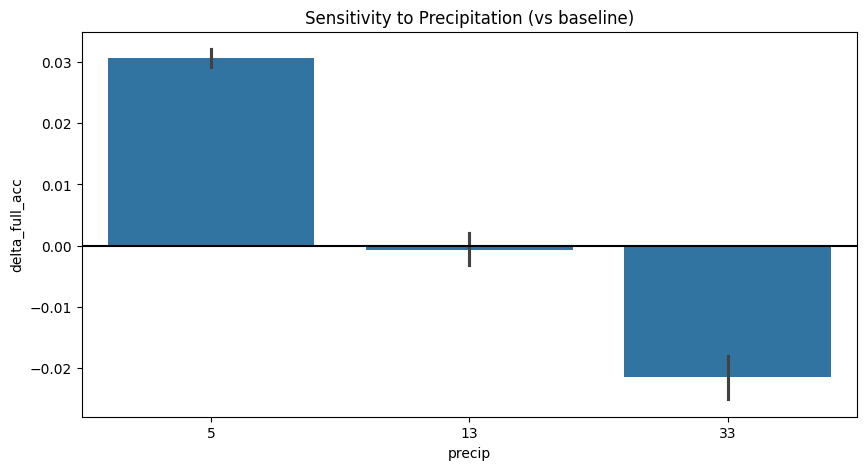

In [4]:
plt.figure(figsize=(10,5))
sns.barplot(data=results_df, x="precip", y="delta_full_acc")
plt.axhline(0, color="black")
plt.title("Sensitivity to Precipitation (vs baseline)")
plt.show()

Graph explanation: When precipitation state is classified as heavy rain > 5, the accuracy increases by an average of .03. Also, bars represent confidence interval and is smaller than classifying heavy rain > 33, highlighting that this is a good way to create states.

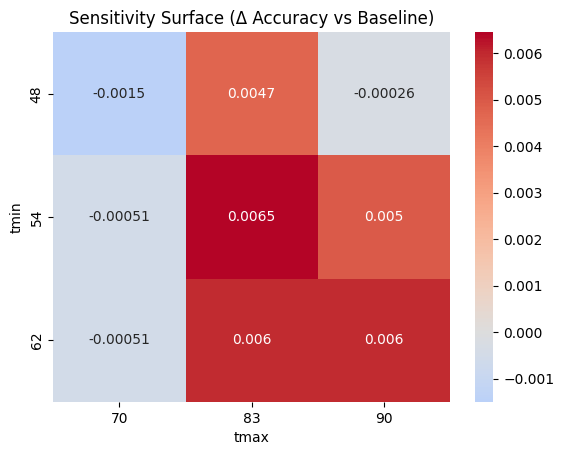

In [5]:
pivot = results_df.pivot_table(
    index="tmin",
    columns="tmax",
    values="delta_full_acc"
)

sns.heatmap(pivot, annot=True, cmap="coolwarm", center=0)
plt.title("Sensitivity Surface (Δ Accuracy vs Baseline)")
plt.show()

Graph explanation: Not many changes between each temperature test, highlighting that precipitation binning is more of an impactful factor on accuracy. However, best combination of tmin and tmax is tmin = 54 and tmax = 83.

In [6]:
best_row_acc_change = results_merged_final.loc[results_merged_final["delta_acc"].idxmax()]
print(best_row_acc_change[['tmax','tmin','precip','model','delta_acc']])

tmax               83
tmin               54
precip              5
model        seasonal
delta_acc     0.11305
Name: 39, dtype: object


In [7]:
best_row = results_merged_final.loc[results_merged_final["acc"].idxmax()]
print(best_row[['tmax','tmin','precip','model','acc']])

tmax            83
tmin            54
precip           5
model     seasonal
acc       0.806926
Name: 39, dtype: object


In [8]:
best_next_day = results_merged_final.loc[results_merged_final["acc_1"].idxmax()]
print(best_next_day[['tmax','tmin','precip','model','acc_1']])

tmax            70
tmin            48
precip           5
model     seasonal
acc_1     0.857143
Name: 27, dtype: object


In [9]:
best_log = results_merged_final.loc[results_merged_final["delta_log_likel"].idxmax()]
print(best_log[['tmax','tmin','precip','model','delta_log_likel']])

tmax                     83
tmin                     62
precip                    5
model              seasonal
delta_log_likel    0.221783
Name: 42, dtype: object


In [10]:
best_long_term = results_merged_final.loc[results_merged_final["acc_14"].idxmax()]
print(best_long_term[['tmax','tmin','precip','model','acc_14']])

tmax            70
tmin            48
precip           5
model     seasonal
acc_14    0.767802
Name: 27, dtype: object
